In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R
import random 

import time 

root_dir = os.path.abspath('..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.models.dpso_train import DPSO_train as DPSO

from src.data_loader.data_module_lightning import SonarSimDataModule


# from training.metrics import pose_err


In [4]:
model_config_pth = '/home/mjanis/workspace/SonarOdometry/config/model.yaml'
sonar_config_pth = '/home/mjanis/workspace/SonarOdometry/config/sonar.yaml'

root_dir = '/home/mjanis/workspace/SonarOdometry/data'
batch_size = 1
num_workers = 0
transforms = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(model_config_pth, "r") as f:
            model_config = Box(yaml.safe_load(f))

frames_in_series = 8
init_frames = 4

dm = SonarSimDataModule(root_dir, batch_size, num_workers, transforms, frames_in_series)
dm.setup(stage='fit')
train_data_loader = dm.train_dataloader()

batch = next(iter(train_data_loader))
series, time, trajectory, depth = batch

print(series.shape)
print(time.shape)
print(trajectory.shape)
print(depth.shape)



torch.Size([1, 8, 1, 800, 768])
torch.Size([1, 8, 1])
torch.Size([1, 8, 7])
torch.Size([1, 8, 1])


# **Training test**

In [5]:
dpso_t = DPSO(model_config_pth, sonar_config_pth, batch_size, frames_in_series, init_frames, device)

dpso_t.train()

DPSO_train(
  (PatchGraph): Graph(
    (patchifier): Patchifier(
      (feature_extractor): Encoder(
        (conv1): Conv2d(1, 32, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (ResBlock1): Sequential(
          (0): ResidualBlock(
            (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (norm1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (norm2): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          )
          (1): ResidualBlock(
            (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (conv2): Conv2d(32, 32, kernel_size=(3, 3

In [6]:
optimizer = torch.optim.Adam(dpso_t.parameters(), lr=1e-4)

test_iter = 2
w1 = 1.0
w2 = 1.0
w3 = 1.0
w4 = 1.0

for i in range(test_iter):

    optimizer.zero_grad()

    loss = 0.0

    batch = next(iter(train_data_loader))
    series, time, trajectory, depth = batch

    pred = dpso_t(series, time, trajectory, depth, freeze_poses=True, init_poses_noise = 0.0, debug_logger=True)

    for k, (pred_poses, pred_coords, gt_coords) in enumerate(pred):
        
        trans_err, rot_err = pose_err(pred_poses, trajectory)

        patch_proj_err = torch.abs(gt_coords - pred_coords)
        proj_x_err = torch.mean(patch_proj_err[:, 0], dim=-1)
        proj_y_err = torch.mean(patch_proj_err[:, 1], dim=-1)

        # add weights: 
        
        loss += w1*trans_err + w2*rot_err + w3*proj_x_err + w4*proj_y_err
        print('loss components', trans_err, rot_err, proj_x_err, proj_y_err)

    
    print(f'Iter: {i}, total loss: {loss}')

    loss.backward()
    optimizer.step()


Processing: frame 0/7


RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)

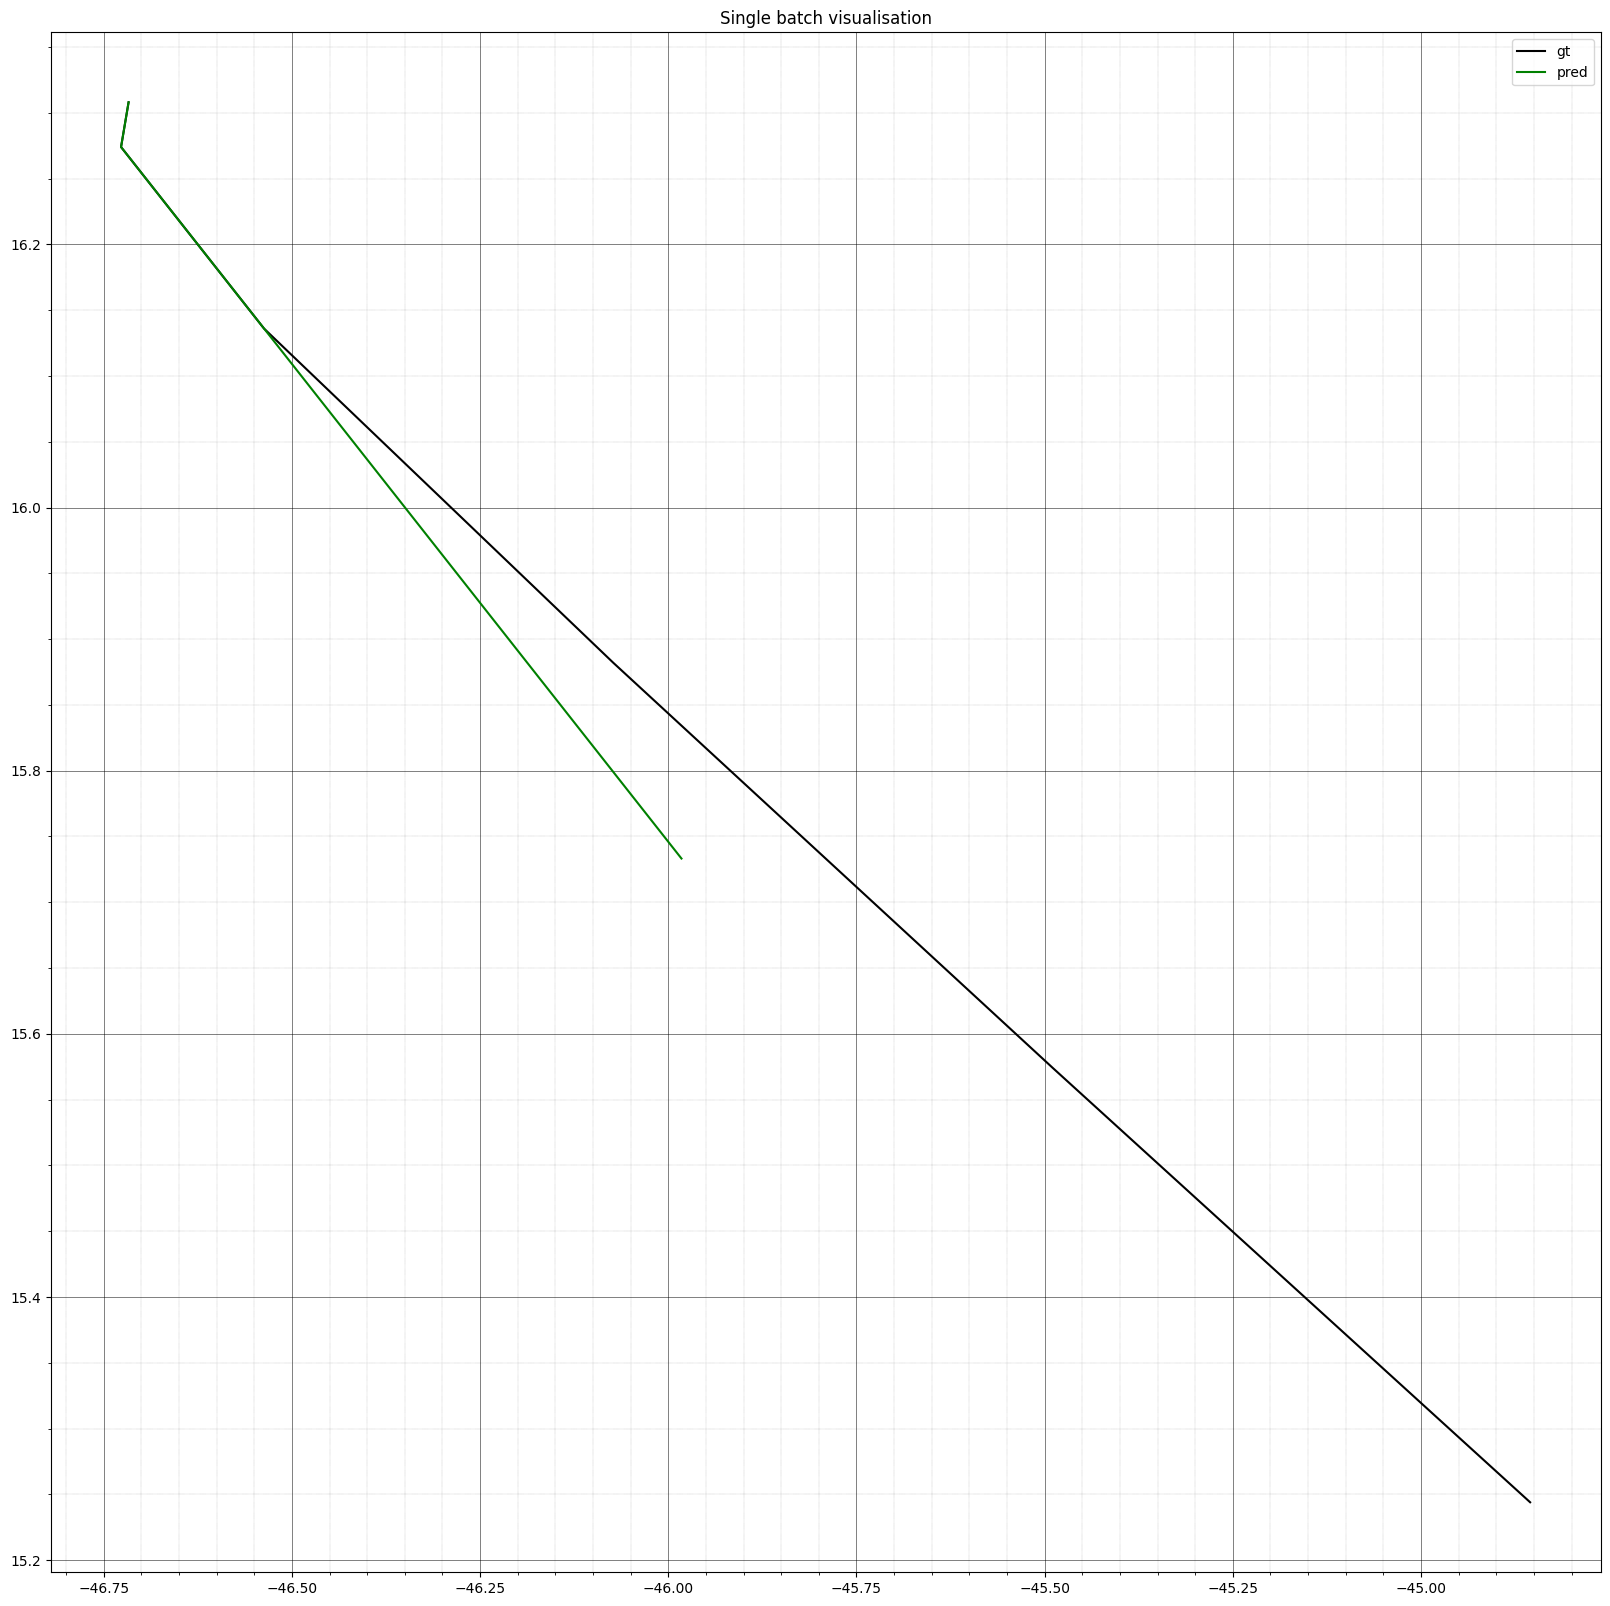

In [ ]:
# plot predictions 
import matplotlib.pyplot as plt

batch_number = 1 #trajectory.shape[0]

use_axis = (0, 1) # x, y

fig, ax = plt.subplots(figsize=(20,20))

trajectory_np = trajectory.detach().clone().cpu().numpy()
pred_np = pred[-1][0].detach().clone().cpu().numpy()

for b in range(batch_number):

    gt_xyz = trajectory_np[b, :, :3]
    pred_xyz = pred_np[b, :, :3]

    ax.plot(gt_xyz[:, use_axis[0]], gt_xyz[:, use_axis[1]], color='black', alpha=1, label='gt')
    ax.plot(pred_xyz[:, use_axis[0]], pred_xyz[:, use_axis[1]], color='green', alpha=1, label='pred')

ax.set_title(f"Single batch visualisation")
ax.minorticks_on()
ax.grid(which='major', linestyle='-', linewidth='0.5', color='black', alpha=0.7)
ax.grid(which='minor', linestyle=':', linewidth='0.3', color='black', alpha=0.5)
ax.legend()


plt.show()

In [ ]:
# save state dict 

ckpt_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/training/test_output/test_ckpt.ckpt'
torch.save(dpso_t.state_dict(), ckpt_pth)